# Expected returns estimation

The sample mean is the noisiest ingredient in portfolio optimisation. With only a year of
daily data the per-asset average return is estimated very imprecisely, and any optimiser that
*chases* return — maximum return, maximum risk-adjusted ratio, high-risk-aversion utility —
amplifies that noise into extreme, unstable weights. **Shrinkage** estimators pull the raw
sample mean toward a structured target, trading a little bias for a large reduction in
variance.

`PortfolioOptimisers` exposes the expected-returns estimator as the `me` field of a prior.
The default is the plain sample mean (`SimpleExpectedReturns`); the shrinkage
estimator `ShrunkExpectedReturns` wraps it with an algorithm —
`BayesStein`, `BodnarOkhrinParolya` or `JamesStein` — each of which
shrinks toward one of three targets: `GrandMean`, `VolatilityWeighted` or
`MeanSquaredError`.

> **When to reach for this**
>
> Reach for a shrunk expected-returns estimator whenever your objective depends on the mean
> — `MaximumReturn`, `MaximumRatio`, or a risk-averse
> `MaximumUtility` — and especially when the estimation window is short relative to
> the number of assets. If you only ever run `MinimumRisk` or risk-budgeting (which
> ignore the mean), the estimator hardly matters and the default is fine.

In [1]:
using PortfolioOptimisers, PrettyTables

mmtfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=4)) %" : v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Expected-returns estimators

We build one prior per estimator, varying **only** the `me` field so the covariance is
identical across them — any difference in the optimisation later is due purely to the expected
returns. We compare the plain sample mean against Bayes–Stein, Bodnar–Okhrin–Parolya and
James–Stein shrinkage toward different targets.

In [3]:
mes = ["Vanilla" => SimpleExpectedReturns(),
       "BS(GM)" => ShrunkExpectedReturns(; alg = BayesStein(; tgt = GrandMean())),
       "BS(VW)" => ShrunkExpectedReturns(; alg = BayesStein(; tgt = VolatilityWeighted())),
       "BOP(MSE)" =>
           ShrunkExpectedReturns(; alg = BodnarOkhrinParolya(; tgt = MeanSquaredError())),
       "JS(GM)" => ShrunkExpectedReturns(; alg = JamesStein(; tgt = GrandMean()))]

prs = [k => prior(EmpiricalPrior(; me = me), rd) for (k, me) in mes]

5-element Vector{Pair{String, LowOrderPrior{Matrix{Float64}, Vector{Float64}, Matrix{Float64}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing}}}:
  "Vanilla" => LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ nothing
     f_mu ┼ nothing
  f_sigma ┼ nothing
      f_w ┴ nothing

   "BS(GM)" => LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ nothing
     f_mu ┼ nothing
  f_sigma ┼ nothing
      f_w ┴ nothing

   "BS(VW)" => LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      en

The expected-returns vectors side by side. Note that shrinkage toward the grand mean
(`BS(GM)`, `JS(GM)`) preserves the cross-sectional average while pulling the spread in, whereas
volatility-weighted and MSE targets shift the level too.

In [4]:
pretty_table(DataFrame(["Assets" => rd.nx; [k => p.mu for (k, p) in prs]]);
             formatters = [mmtfmt], title = "Expected returns by estimator")

                    Expected returns by estimator
┌────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ Assets │   Vanilla │    BS(GM) │    BS(VW) │  BOP(MSE) │    JS(GM) │
│ String │   Float64 │   Float64 │   Float64 │   Float64 │   Float64 │
├────────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│   AAPL │ -0.1126 % │ -0.0378 % │  0.0088 % │  0.0631 % │ -0.0951 % │
│    AMD │ -0.2809 % │ -0.1073 % │ -0.0565 % │  0.1574 % │ -0.2402 % │
│    BAC │ -0.0934 % │ -0.0299 % │  0.0162 % │  0.0524 % │ -0.0785 % │
│    BBY │ -0.0279 % │ -0.0029 % │  0.0416 % │  0.0157 % │  -0.022 % │
│    CVX │  0.1945 % │  0.0889 % │  0.1278 % │ -0.1089 % │  0.1698 % │
│     GE │ -0.0339 % │ -0.0054 % │  0.0393 % │   0.019 % │ -0.0272 % │
│     HD │ -0.0707 % │ -0.0205 % │   0.025 % │  0.0397 % │  -0.059 % │
│    JNJ │  0.0307 % │  0.0213 % │  0.0643 % │ -0.0172 % │  0.0285 % │
│    JPM │ -0.0417 % │ -0.0086 % │  0.0363 % │  0.0234 % │ -0.0339 % │
│     KO │  0.0497 % │  0.0

## 3. Visualising the shrinkage

`plot_mu` makes the pull-toward-target visible: compared with the raw sample mean, the
shrunk estimator compresses the dispersion of the per-asset expected returns.

Vanilla sample-mean expected returns.

In [5]:
using StatsPlots, GraphRecipes

Bayes–Stein (volatility-weighted target) expected returns.

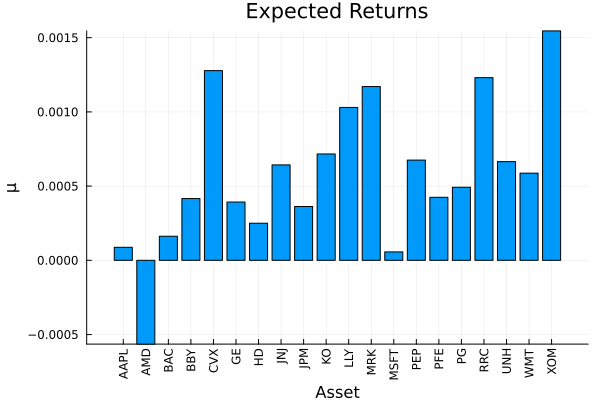

In [6]:
plot_mu(prs[1].second, rd.nx)
plot_mu(prs[3].second, rd.nx)

## 4. Why it matters: a return-seeking optimisation

Expected returns only bite when the objective uses them. We maximise the risk-adjusted ratio
with each prior in turn (same covariance, different mean) and compare the resulting weights.
The noisy sample mean concentrates; shrinkage spreads the allocation out and stabilises it.

In [7]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

ress = [k => optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                               opt = JuMPOptimiser(; pe = p, slv = slv))) for (k, p) in prs]

pretty_table(DataFrame(["Assets" => rd.nx; [k => r.w for (k, r) in ress]]);
             formatters = [resfmt], title = "Maximum-ratio weights by mu estimator")

              Maximum-ratio weights by mu estimator
┌────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ Assets │  Vanilla │   BS(GM) │   BS(VW) │ BOP(MSE) │   JS(GM) │
│ String │  Float64 │  Float64 │  Float64 │  Float64 │  Float64 │
├────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
│   AAPL │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    AMD │    0.0 % │    0.0 % │    0.0 % │  100.0 % │    0.0 % │
│    BAC │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    BBY │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    CVX │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│     GE │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│     HD │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    JNJ │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│    JPM │    0.0 % │    0.0 % │    0.0 % │    0.0 % │    0.0 % │
│     KO │    0.0 % │    0.0 % │  7.015 % │    0.0 % │    0.0 % │
│    LLY │  0.002 % │   

The composition plot drives the point home: swapping the expected-returns estimator alone
reshapes the maximum-ratio portfolio.

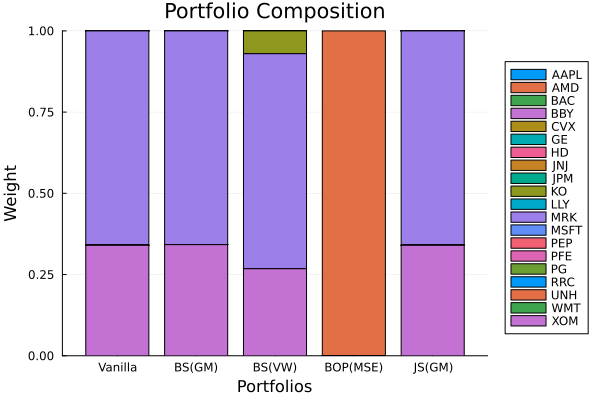

In [8]:
plot_stacked_bar_composition([r for (_, r) in ress], rd;
                             xticks = (1:length(ress), [k for (k, _) in ress]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*